In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR10 — Milli valyutanın ABŞ dollarına və avroya nisbətdə orta illik məzənnəsinin təhlili və proqnazlaşdırılması

Milli valyutanın ABŞ dollarına və avroya nisbətdə orta illik məzənnəsinin təhlili və proqnozlaşdırılması (MİİS §15.5.1, bənd 2.4.1.5.-7.).

## 1. Tələb

**Spesifikasiyanın mətni (§15.5.1, FR10):** "Milli valyutanın ABŞ dollarına və avroya nisbətdə orta illik məzənnəsinin təhlili və proqnozlaşdırılması."

Tələb iki ayrı, lakin bir-biri ilə bağlı göstərici üzərində qurulur: manatın ABŞ dollarına nisbətdə (AZN/USD) və avroya nisbətdə (AZN/EUR) **orta illik** məzənnəsi. Hər iki sıra paketin başqa heç bir yerində qiymətləndirilmədiyi, lakin demək olar bütün digər FR-lərin (xarici ticarət, tədiyə balansı, adambaşına düşən ÜDM-in dollar ifadəsi) **ekzogen girişi** kimi işlədiyi üçün icra DAG-ında ən erkən mərhələlərdən birinə qoyulub (FR5-dən dərhal sonra, FR9-dan əvvəl — bax `_internal/BUILD_CONTEXT.md` §D2).

**Bu buraxılışda dəyişən üç şey.** (i) Spesifikasiyanın tələb etdiyi **orta illik** anlayışı artıq öz sırası ilə təmin olunur: Mərkəzi Bankın 2.16 nömrəli cədvəli rəsmi orta illik məzənnəni 1995-ci ilə qədər dərc edir; əvvəlki buraxılış onun yerinə **dövrün sonuna** sırasını işlədirdi (uçot səhvi, aşağıda ədədlə ölçülür). (ii) AZN/EUR artıq **xarici, tək tarixli ECB istinadı ilə çarpaz hesablanmır** — 1999–2025 dövrünü əhatə edən faktiki AMB sırası üzərində modelləşdirilir və yelpik zolağı həmin sıranın **öz** volatilliyindən qurulur. (iii) Hər iki göstərici üçün namizəd modellər eyni pəncərədə, eyni etalona qarşı **yarışdırılır** (D4); əvvəlki buraxılışda AZN/EUR üçün heç bir yarış aparıla bilmirdi, çünki tarixi sıra yox idi.

## 2. Məlumat

İstifadə olunan sıralar (hamısı ≤ 2025, HƏMİŞƏ faktiki):

| `series_code` / açar | Təsvir | Vahid | Mənbə | Əhatə |
|---|---|---|---|---|
| `fx_usd_azn_avg` | ABŞ dollarının **rəsmi orta illik** məzənnəsi | AZN/USD | AMB, cədvəl **2.16**, sütun B | **1995–2025** |
| `fx_eur_azn` | Avronun **rəsmi orta illik** məzənnəsi | AZN/EUR | AMB, cədvəl **2.16**, sütun C | **1999–2025** |
| `fx_usd_azn_ssc`, `fx_eur_azn_ssc` | DSK-nın implisit məzənnələri (müstəqil çarpaz yoxlama) | AZN/USD, AZN/EUR | DSK, cədvəl 10 (`010en`) | 1990/1999–2025 |
| `fx_usd_azn_eop` | ABŞ dollarının məzənnəsi, **dövrün sonuna** | AZN/USD | Monetar sektoru, sətir 114 | 1995–2025 |
| `fx_usd_azn` | Aylıq **dövrün sonuna** müşahidələrin ortalaması | AZN/USD | Monetar sektoru, sətir 114 | 2021–2025 |

**Uçot düzəlişi (eop → orta illik).** Əvvəlki buraxılış həm proqnozun bazasını, həm geriyə doğru sınağını `fx_usd_azn_eop` (dövrün sonuna) sırası üzərində qururdu, halbuki spesifikasiya **orta illik** məzənnəni tələb edir. Peg dövründə (2017-dən) iki anlayış üst-üstə düşdüyü üçün fərq görünmürdü; 2015–2016 devalvasiya illərində isə fərq böyükdür və aşağıda ədədlə göstərilir. Bu buraxılışda **bütün qiymətləndirmə, sınaq və nəşr orta illik sıra üzərində aparılır**; dövrün sonuna sırası yalnız müqayisə üçün saxlanılır.

Şablonun (8 vərəq) 2.4.1.5.-7. bölməsindəki 30 və 31-ci sətirlər (orta illik AZN/USD və AZN/EUR) bütün illər üzrə `#REF!` qaytarır — bu, sıranın **mövcud olmaması** deyil, şablonun daxili istinadının qırılmasıdır; sıraların özü AMB-nin nəşrindədir.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LA, FY = config.LAST_ACTUAL, list(config.FY)

# RƏSMİ ORTA İLLİK məzənnələr — AMB cədvəl 2.16 (§14 açıq mənbə paneli)
fx_usd_avg = data_layer.public_series("fx_usd_azn_avg")     # 1995-2025
fx_eur = data_layer.public_series("fx_eur_azn")             # 1999-2025
# müqayisə üçün saxlanılan iş kitabı sıraları
fx_usd_eop = data_layer.actuals("fx_usd_azn_eop")           # dövrün sonuna, 1995-2025
fx_usd_wb = data_layer.actuals("fx_usd_azn")                # aylıq eop ortalaması, 2021-2025

print("PROVENANS —", data_layer.PUBLIC_SOURCE_NOTE)
print()
print(pd.DataFrame({"AZN/USD orta illik (AMB 2.16)": fx_usd_avg,
                    "AZN/USD dövrün sonuna (iş kitabı)": fx_usd_eop,
                    "AZN/EUR orta illik (AMB 2.16)": fx_eur}).round(5).to_string())

PROVENANS — Rəsmi açıq mənbələr: DSK (Dövlət Statistika Komitəsi) nəşr cədvəlləri, AMB (Mərkəzi Bank) monetar göstəriciləri və NSDP buraxılışı, opendata.az açıq məlumat resursu, Nazirliyin MOE BOP iş kitabı. Anlıq nüsxə 2026-06-03. Hər sıra üçün gözlənilən etiket `PUBLIC_SPEC`-də saxlanılır və `verify_public_panel()` tərəfindən yoxlanılır

      AZN/USD orta illik (AMB 2.16)  AZN/USD dövrün sonuna (iş kitabı)  AZN/EUR orta illik (AMB 2.16)
1995                        0.88282                             0.8880                            NaN
1996                        0.86052                             0.8196                            NaN
1997                        0.79733                             0.7776                            NaN
1998                        0.77376                             0.7780                            NaN
1999                        0.82364                             0.8756                        0.87812
2000                        0.89485           

**Uçot düzəlişinin ölçüsü.** Aşağıdakı cədvəl orta illik və dövrün sonuna sıralarının fərqini bütün illər üzrə hesablayır. Fərq yalnız məzənnənin il ərzində hərəkət etdiyi illərdə sıfırdan fərqlidir.

In [3]:
_gap = (fx_usd_avg - fx_usd_eop).dropna()
_top = _gap.abs().sort_values(ascending=False).head(6)
print("orta illik − dövrün sonuna, ən böyük fərqli 6 il (AZN/USD):")
print(pd.DataFrame({"orta illik": fx_usd_avg.reindex(_top.index),
                    "dövrün sonuna": fx_usd_eop.reindex(_top.index),
                    "fərq": _gap.reindex(_top.index),
                    "fərq, %": (_gap / fx_usd_eop * 100).reindex(_top.index)})
      .sort_index().round(4).to_string())
print()
print(f"maksimal mütləq fərq = {_gap.abs().max():.4f} AZN ({int(_gap.abs().idxmax())}-ci il, "
      f"{abs(float(_gap.loc[_gap.abs().idxmax()] / fx_usd_eop.loc[_gap.abs().idxmax()] * 100)):.1f} %)")
print(f"2017-2025 (peg) alt-pəncərəsində maksimal fərq = {_gap.loc[2017:].abs().max():.4f} AZN")
print("Ona görə peg dövründə uçot seçimi nəticəyə təsir etmir, 2015-2016 üçün isə həlledicidir.")

# iş kitabının 2021-2025 sırası nə ölçür: aylıq DÖVRÜN SONUNA müşahidələrin ortalaması
print()
print("iş kitabının `fx_usd_azn` sırası (2021-2025) ilə AMB-nin orta illik sırası:")
print(pd.DataFrame({"iş kitabı": fx_usd_wb, "AMB 2.16": fx_usd_avg.reindex(fx_usd_wb.index),
                    "fərq": fx_usd_wb - fx_usd_avg.reindex(fx_usd_wb.index)}).round(6).to_string())

orta illik − dövrün sonuna, ən böyük fərqli 6 il (AZN/USD):
      orta illik  dövrün sonuna    fərq  fərq, %
1996      0.8605         0.8196  0.0409   4.9921
1999      0.8236         0.8756 -0.0520  -5.9346
2001      0.9313         0.9550 -0.0237  -2.4826
2005      0.9459         0.9186  0.0273   2.9756
2015      1.0261         1.5594 -0.5333 -34.1964
2016      1.5959         1.7700 -0.1741  -9.8374

maksimal mütləq fərq = 0.5333 AZN (2015-ci il, 34.2 %)
2017-2025 (peg) alt-pəncərəsində maksimal fərq = 0.0212 AZN
Ona görə peg dövründə uçot seçimi nəticəyə təsir etmir, 2015-2016 üçün isə həlledicidir.

iş kitabının `fx_usd_azn` sırası (2021-2025) ilə AMB-nin orta illik sırası:
      iş kitabı  AMB 2.16  fərq
year                           
2021        1.7       1.7  -0.0
2022        1.7       1.7  -0.0
2023        1.7       1.7  -0.0
2024        1.7       1.7  -0.0
2025        1.7       1.7  -0.0


**Müstəqil çarpaz yoxlama.** AMB-nin 2.16 cədvəli DSK-nın 10 nömrəli cədvəlinin implisit məzənnələri ilə (ÜDM manatla ÷ ÜDM dollarla, ÜDM avro ilə) tutuşdurulur. İki mənbə bir-birindən asılı deyil: DSK-nın məzənnəsi ÜDM-in manat və dollar (avro) ifadələrinin nisbətindən **implisit** çıxır, AMB-ninki isə gündəlik rəsmi məzənnələrin ortalamasıdır. DSK dörd onluq işarə ilə dərc etdiyi üçün müqayisə həmin dəqiqliyə yuvarlaqlaşdırılır; qalan fərq implisit hesablamanın yuvarlaqlaşdırma qalığıdır və 0,003 AZN-i keçmir.

In [4]:
cc = data_layer.fx_cross_check()
print("AMB 2.16 ↔ DSK 010en — orta illik məzənnələrin müstəqil tutuşdurulması:")
print(cc.to_string(index=False))
FX_XCHECK_TOL = 3e-3          # implisit hesablamanın yuvarlaqlaşdırma qalığı üçün hədd
assert bool((cc["max_abs_diff"] <= FX_XCHECK_TOL).all()), "iki mənbə arasında gözlənilməz fərq"
assert bool((cc["diff_2025"].abs() <= 1e-9).all()), "2025-ci ildə iki mənbə eyni olmalıdır"
print()
print(f"Maksimal fərq {float(cc['max_abs_diff'].max()):.4f} AZN — yuvarlaqlaşdırma həddi "
      f"({FX_XCHECK_TOL}) daxilindədir; {LA}-ci ildə iki mənbə DƏQİQ eynidir (1,9210).")
# DİQQƏT: cədvəldəki `n_within_tol` sütunu BAŞQA, daha dar tolerantlıqla (fx_cross_check-in öz
# 5e-4 defoltu) hesablanır və qəbul şərti DEYİL. Qəbul şərti yuxarıdakı assert-dir
# (max_abs_diff ≤ 3e-3). İki ədədin qarışdırılmaması üçün fərq açıq yazılır.
print(f"«n_within_tol» sütunu 5e-4 həddi ilə sayılır (qəbul şərti deyil): "
      f"{', '.join(f'{r.pair}: {r.n_within_tol}/{r.n_overlap}' for r in cc.itertuples())}; "
      f"həmin hədddən kənarda qalan illərin hamısı 3e-3 daxilindədir.")

AMB 2.16 ↔ DSK 010en — orta illik məzənnələrin müstəqil tutuşdurulması:
   pair           cbar            ssc  n_overlap  n_within_tol  max_abs_diff  max_diff_year  diff_2025  diff_2015
AZN/USD fx_usd_azn_avg fx_usd_azn_ssc         31            28        0.0014           1996        0.0     0.0000
AZN/EUR     fx_eur_azn fx_eur_azn_ssc         27            21        0.0028           2010        0.0     0.0001

Maksimal fərq 0.0028 AZN — yuvarlaqlaşdırma həddi (0.003) daxilindədir; 2025-ci ildə iki mənbə DƏQİQ eynidir (1,9210).
«n_within_tol» sütunu 5e-4 həddi ilə sayılır (qəbul şərti deyil): AZN/USD: 28/31, AZN/EUR: 21/27; həmin hədddən kənarda qalan illərin hamısı 3e-3 daxilindədir.


In [5]:
gaps = data_layer.data_gaps()
print("FR10-un məlumat boşluğu qeydləri (hər ikisi BAĞLANDI):")
for _, r in gaps[gaps["series_code"].str.startswith("fx_")].iterrows():
    print(f"\n· {r['series_code']}\n  {r['problem_az']}\n  → {r['treatment_az']}")

FR10-un məlumat boşluğu qeydləri (hər ikisi BAĞLANDI):

· fx_eur_azn
  BAĞLANDI. Əvvəllər manatın avroya nisbətdə məzənnəsinin nə iş kitabında, nə statutar şablonda olmadığı qeyd edilirdi (şablonun 31-ci sətri bütün illər üzrə #REF! qaytarır) — bu, YANLIŞ idi: sıra AMB-nin 2.16 cədvəlində 1999–2025 üçün rəsmi orta illik məzənnə kimi dərc olunur.
  → TAM BAĞLANDI. `fx_eur_azn` sırası AMB cədvəl 2.16 (AVRO sütunu) əsasında məlumat qatına daxil edilib (1999–2025) və DSK 010en-in implisit məzənnəsi ilə müstəqil tutuşdurulub (2025: hər iki mənbədə 1,9210). FR10 ARTIQ çarpaz məzənnə hesablamır və xarici ECB istinadından istifadə etmir: faktiki sıra üzərində peg arifmetikası ilə təsadüfi gəzişmə yarışdırılır, yelpik zolağının sigması isə həmin sıranın peg dövrünün öz volatilliyindən qiymətləndirilir.

· fx_usd_azn
  BAĞLANDI. Əvvəllər orta illik AZN/USD məzənnəsinin yalnız 2021–2025 üçün hesablana bildiyi qeyd edilirdi (şablonun 30-cu sətri tam #REF!, iş kitabında yalnız dövrün sonuna sıra) —

In [6]:
# Nazirliyin öz Proqnoz sütunlarında məzənnə sətri axtarılır (yalnız müqayisə üçün).
for _code in ("fx_usd_azn", "fx_usd_azn_eop"):
    try:
        mb = data_layer.ministry_baseline(_code)
        print(f"Nazirliyin `{_code}` Proqnoz sırası:",
              "boşdur (mövcud deyil)" if mb.empty else mb.to_dict())
    except Exception as e:
        print(f"Nazirliyin `{_code}` Proqnoz sırası oxuna bilmədi:", e)

Nazirliyin `fx_usd_azn` Proqnoz sırası: boşdur (mövcud deyil)
Nazirliyin `fx_usd_azn_eop` Proqnoz sırası: boşdur (mövcud deyil)


## 3. Model seçimi

**AZN/USD.** 2017-ci ildən manat ABŞ dollarına faktiki olaraq **1,70 səviyyəsində bağlanıb**. Bu, ekonometrik cəhətdən qiymətləndirilməli bir davranış tənliyi deyil, Mərkəzi Bankın elan edilmiş **valyuta rejimidir**; ona görə 2026–2030 yolu **rejim fərziyyəsi** kimi düz xətt (1,70) olaraq təyin olunur. Rejim fərziyyəsinin təsadüfi gəzişmə (RW) etalonuna qarşı bacarığı Bölmə 6-da ölçülür — və orta illik sıra üzərində nəticə dövrün sonuna sırasında olduğundan **fərqlidir**: 2018-ci ildə orta illik məzənnə 1,700018, 2017-ci ildə isə 1,721151 olduğu üçün RW peg-in ilk ilində xəta verir, rejim fərziyyəsi isə vermir.

**AZN/EUR.** Manat dollara bağlı olduğundan avro məzənnəsi tam olaraq **EUR/USD çarpazının** hərəkətidir. İki oxunuş bir-biri ilə yarışdırılır:

1. **Peg arifmetikası** — $\text{AZN/EUR}_t = 1{,}70 \times (\text{EUR/USD})_t$, burada EUR/USD çarpazı sıranın öz tarixçəsindən götürülür (son müşahidə və ya son üç ilin ortası). Bu forma rejim biliyini açıq şəkildə tənliyə qoyur.
2. **Birbaşa təsadüfi gəzişmə və dinamik etalonlar** — sıranın öz səviyyəsi üzərində RW, sürüşmə (drift), beş illik orta və loqarifmik AR(1) (orta qiymətə qayıdış).

Seçim **sınağın nəticəsinə** görə edilir (D4), əvvəlcədən deyil. Yelpik zolağı üçün lazım olan illik volatillik artıq kalibrlənmir — **faktiki sıradan qiymətləndirilir** (Bölmə 5).

## 4. Testlər

İki sınaq aparılır: (i) peg rejiminin təsviri statistikası — orta illik sıranın dispersiyası 2018–2025 dövründə; (ii) AZN/EUR səviyyəsinin vahid kök sınağı (ADF), çünki model seçimi səviyyə/fərq qərarından asılıdır.

In [7]:
post_peg = fx_usd_avg.loc[2018:]
pre_peg = fx_usd_avg.loc[1995:2014]
print(f"AZN/USD 2018-2025 (peg):     n={len(post_peg)}, orta={post_peg.mean():.6f}, "
      f"std={post_peg.std():.8f}")
print(f"AZN/USD 1995-2014 (peg-dən əvvəl): n={len(pre_peg)}, orta={pre_peg.mean():.4f}, "
      f"std={pre_peg.std():.4f}")
print(f"AZN/USD 2015-2017 (keçid): {fx_usd_avg.loc[2015:2017].round(6).to_dict()}")
print()
print(ek.adf(np.log(fx_eur), "ln(AZN/EUR), səviyyə, 1999-2025", maxlag=2))
print(ek.adf(np.log(fx_eur).diff().dropna(), "Δln(AZN/EUR), 2000-2025", maxlag=2))

AZN/USD 2018-2025 (peg):     n=8, orta=1.700002, std=0.00000646
AZN/USD 1995-2014 (peg-dən əvvəl): n=20, orta=0.8585, std=0.0727
AZN/USD 2015-2017 (keçid): {2015: 1.026141, 2016: 1.595878, 2017: 1.721151}

ADF[ln(AZN/EUR), səviyyə, 1999-2025] stat=-1.477 p=0.5449 lag=1 n=25 kritik(1%: -3.72, 10%: -2.63, 5%: -2.99) → vahid kök
ADF[Δln(AZN/EUR), 2000-2025] stat=-3.687 p=0.0043 lag=0 n=25 kritik(1%: -3.72, 10%: -2.63, 5%: -2.99) → stasionar


**Oxunuş.** Səviyyədə vahid kök rədd edilmir, birinci fərqdə isə stasionarlıq təsdiqlənir — yəni AZN/EUR üçün doğru spesifikasiya səviyyə tənliyi deyil, **fərq (təsadüfi gəzişmə ailəsi)** spesifikasiyasıdır. Bu, Bölmə 6-nın yarışına daxil edilən namizəd dəstini müəyyən edir: yarışa girən beş namizədin dördü (RW, sürüşmə, beş illik orta, peg arifmetikasının iki forması) məhz fərq ailəsindəndir. Loqarifmik AR(1) də tam hüquqlu namizəd kimi yarışa daxil edilir — səviyyə spesifikasiyası ADF-ə görə üstünlük təşkil etmədiyi halda belə, onun sınaqda necə çıxış etdiyi ölçülür və nəticə cədvəldə göstərilir.

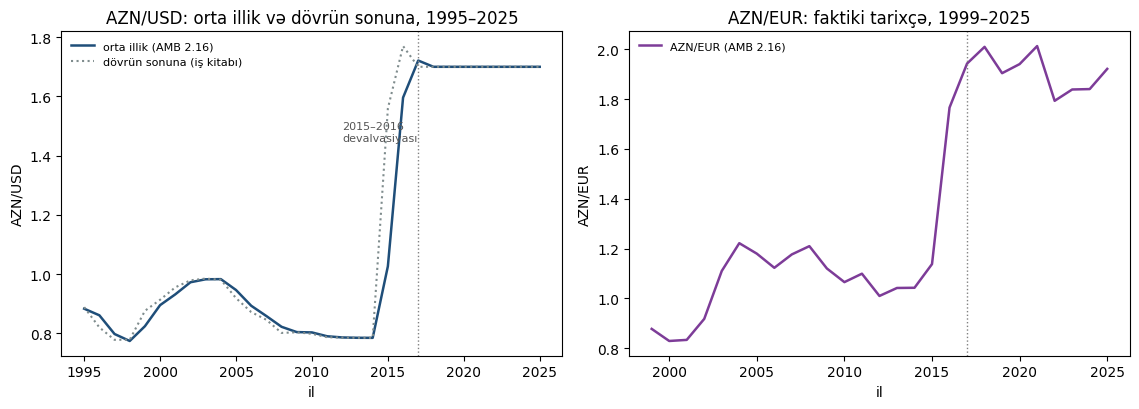

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
ax.plot(fx_usd_avg.index, fx_usd_avg.values, "-", color="#1f4e79", lw=1.8, label="orta illik (AMB 2.16)")
ax.plot(fx_usd_eop.index, fx_usd_eop.values, ":", color="#7f8c8d", lw=1.5, label="dövrün sonuna (iş kitabı)")
ax.axvline(2017, color="grey", ls=":", lw=1)
ax.set_title("AZN/USD: orta illik və dövrün sonuna, 1995–2025")
ax.set_ylabel("AZN/USD"); ax.set_xlabel("il")
ax.legend(loc="upper left", frameon=False, fontsize=8)
ax.annotate("2015–2016\ndevalvasiyası", xy=(2012.0, 1.45), fontsize=8, color="#555555")

ax = axes[1]
ax.plot(fx_eur.index, fx_eur.values, "-", color="#7d3c98", lw=1.8, label="AZN/EUR (AMB 2.16)")
ax.axvline(2017, color="grey", ls=":", lw=1)
ax.set_title("AZN/EUR: faktiki tarixçə, 1999–2025")
ax.set_ylabel("AZN/EUR"); ax.set_xlabel("il")
ax.legend(loc="upper left", frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR10_usd_azn_history.png"), dpi=140)
plt.show()

## 5. Qiymətləndirmə

Bu bölmədə `ols_hac`/`ardl_ecm` tipli davranış tənliyi qiymətləndirilmir və `outputs/equations_catalog.csv`-ə sətir yazılmır: AZN/USD elan edilmiş rejimdir, AZN/EUR isə (Bölmə 4-ün ADF nəticəsinə görə) təsadüfi gəzişmə ailəsindəndir — hər iki halda nəşr olunan kəmiyyət tənlik əmsalı deyil, **yol qaydası və onun sınaq nəticəsidir**.

Bölmənin iki məhsulu var: (i) sıranın özündən çıxarılan **implisit EUR/USD çarpazı** — peg arifmetikasının girişi; (ii) yelpik zolağı üçün **volatilliyin qiymətləndirilməsi** — artıq ədəbiyyat kalibrləməsi deyil, faktiki sıradan.

In [9]:
# implisit EUR/USD çarpazı: AZN/EUR ÷ AZN/USD (hər ikisi orta illik, eyni mənbə)
cross = (fx_eur / fx_usd_avg.reindex(fx_eur.index)).dropna().rename("eur_usd")
print("implisit EUR/USD çarpazı (AMB 2.16-nın iki sütununun nisbəti):")
print(cross.round(4).to_string())
print()
print(f"son müşahidə ({int(cross.index.max())}): {float(cross.iloc[-1]):.4f}; "
      f"son 3 ilin ortası: {float(cross.iloc[-3:].mean()):.4f}; "
      f"peg dövrünün (2018-{LA}) ortası: {float(cross.loc[2018:].mean()):.4f}")

implisit EUR/USD çarpazı (AMB 2.16-nın iki sütununun nisbəti):
1999    1.0662
2000    0.9271
2001    0.8955
2002    0.9446
2003    1.1306
2004    1.2434
2005    1.2474
2006    1.2581
2007    1.3717
2008    1.4726
2009    1.3939
2010    1.3277
2011    1.3923
2012    1.2858
2013    1.3285
2014    1.3298
2015    1.1091
2016    1.1065
2017    1.1285
2018    1.1820
2019    1.1198
2020    1.1413
2021    1.1838
2022    1.0546
2023    1.0814
2024    1.0824
2025    1.1300

son müşahidə (2025): 1.1300; son 3 ilin ortası: 1.0979; peg dövrünün (2018-2025) ortası: 1.1219


In [10]:
# VOLATİLLİK — faktiki sıradan qiymətləndirilir (əvvəlki buraxılışdakı 7 % ədəbiyyat
# kalibrləməsi ƏVƏZLƏNİR). Üç pəncərə göstərilir; mərkəzi ssenari peg dövrüdür, çünki
# 2017-dən sonra AZN/EUR-un bütün hərəkəti EUR/USD çarpazından gəlir və proqnoz üfüqünün
# rejim fərziyyəsi məhz budur.
dln_eur = np.log(fx_eur).diff().dropna()
VOL_WINDOWS = {
    "tam nümunə (2000–%d)" % LA: dln_eur,
    "peg dövrü (2018–%d)" % LA: dln_eur.loc[2018:],
    "peg-dən əvvəl (2000–2014)": dln_eur.loc[2000:2014],
}
vol_tbl = pd.DataFrame([
    {"pəncərə": k, "n": len(v), "σ(Δln), %": round(float(v.std()) * 100, 2),
     "σ(səviyyə), AZN": round(float(v.std()) * float(fx_eur.loc[LA]), 4)}
    for k, v in VOL_WINDOWS.items()]).set_index("pəncərə")
SIGMA_LOG = float(dln_eur.loc[2018:].std())      # mərkəzi ssenari
print(f"seçilən illik loqarifmik sigma (peg dövrü, n={len(dln_eur.loc[2018:])}): "
      f"{SIGMA_LOG:.4f} ({SIGMA_LOG*100:.2f} %)")
print("əvvəlki buraxılışın ədəbiyyat kalibrləməsi: 7,00 % — indi ölçülmüş dəyərlə əvəzlənib.")

# Pəncərə seçimi YALNIZ rejim arqumenti ilə əsaslandırılmır — hər üç namizəd üçün kalibrləmə
# göstərilir: tarixdə h illik faktiki dəyişmələrin neçə faizi ±1,2816·σ√h zolağına düşür
# (nominal 80 %). Nəticə iki pəncərədə fərqlidir və hər ikisi verilir, çünki hansının uyğun
# olduğu rejim fərziyyəsindən asılıdır — bu, seçimin ZƏİF yeridir və gizlədilmir.
_lf = np.log(fx_eur)
_cal = []
for _nm, _s in [("peg dövrü (2018–%d)" % LA, float(dln_eur.loc[2018:].std())),
                ("peg-dən əvvəl (2000–2014)", float(dln_eur.loc[2000:2014].std())),
                ("tam nümunə (2000–%d)" % LA, float(dln_eur.std()))]:
    _r = {"σ, %": round(_s * 100, 2)}
    for _h in range(1, 6):
        _ch = (_lf.shift(-_h) - _lf).dropna()
        _r[f"tam, h={_h}"] = round(100 * float(np.mean(np.abs(_ch) <= 1.2816 * _s * np.sqrt(_h))), 1)
    for _h in range(1, 4):
        _ch = (_lf.shift(-_h) - _lf).dropna(); _ch = _ch[_ch.index >= 2017]
        _r[f"peg, h={_h}"] = round(100 * float(np.mean(np.abs(_ch) <= 1.2816 * _s * np.sqrt(_h))), 1)
    _cal.append(pd.Series(_r, name=_nm))
print()
print("KALİBRLƏMƏ — nominal 80 % zolağın faktiki əhatəsi, %:")
print(pd.DataFrame(_cal).to_string())
print("  · tam nümunədə seçilən σ AŞAĞI əhatə verir (59–75 % ↔ nominal 80 %), çünki 2015–2016")
print("    devalvasiyasını əhatə edən dəyişmələr onun zolağına sığmır;")
print("  · peg dövründə isə əhatə 87,5–100 %-dir, lakin bu, cəmi 4–8 üst-üstə düşən müşahidəyə")
print("    əsaslanır və özü də sübut sayıla bilməz. Seçim buna görə statistik deyil, REJİM")
print("    fərziyyəsinə söykənir (Bölmə 9-da məhdudiyyət kimi yazılıb).")
vol_tbl

seçilən illik loqarifmik sigma (peg dövrü, n=8): 0.0555 (5.55 %)
əvvəlki buraxılışın ədəbiyyat kalibrləməsi: 7,00 % — indi ölçülmüş dəyərlə əvəzlənib.

KALİBRLƏMƏ — nominal 80 % zolağın faktiki əhatəsi, %:
                            σ, %  tam, h=1  tam, h=2  tam, h=3  tam, h=4  tam, h=5  peg, h=1  peg, h=2  peg, h=3
peg dövrü (2018–2025)       5.55      65.4      72.0      75.0      60.9      59.1      87.5     100.0     100.0
peg-dən əvvəl (2000–2014)   7.56      88.5      84.0      75.0      65.2      59.1      87.5     100.0     100.0
tam nümunə (2000–2025)     10.76      92.3      84.0      75.0      73.9      68.2     100.0     100.0     100.0
  · tam nümunədə seçilən σ AŞAĞI əhatə verir (59–75 % ↔ nominal 80 %), çünki 2015–2016
    devalvasiyasını əhatə edən dəyişmələr onun zolağına sığmır;
  · peg dövründə isə əhatə 87,5–100 %-dir, lakin bu, cəmi 4–8 üst-üstə düşən müşahidəyə
    əsaslanır və özü də sübut sayıla bilməz. Seçim buna görə statistik deyil, REJİM
    fərziyyəsinə sö

,n,"σ(Δln), %","σ(səviyyə), AZN"
pəncərə,,,
tam nümunə (2000–2025),26,10.76,0.2068
peg dövrü (2018–2025),8,5.55,0.1067
peg-dən əvvəl (2000–2014),15,7.56,0.1452


## 6. Geriyə doğru sınaq

Genişlənən pəncərəli, bir addımlıq, nümunədən kənar sınaq. Hər sınaq ili üçün model yalnız ondan əvvəlki illərin məlumatı ilə qurulur.

**AZN/USD** — `REJIM_1.70` (rejim fərziyyəsinin özü, tarixin bütün dövrünə geriyə tətbiq edilmiş halda) `RW` etalonuna qarşı, üç kəsikdə: (a) orta illik sıra, tam pəncərə; (b) orta illik sıra, yalnız peg alt-pəncərəsi (2018–2025); (c) dövrün sonuna sıra, tam pəncərə — uçot düzəlişinin nəticəyə təsirini göstərmək üçün saxlanılır.

In [11]:
def _rejim(train, target_year):
    return config.USD_AZN_PEG


bt_usd = ek.backtest(pd.DataFrame({"y": fx_usd_avg}), {"REJIM_1.70": _rejim}, min_train=8,
                     series_code="fx_usd_azn_avg", verbose=True)
bt_usd_peg = ek.backtest(pd.DataFrame({"y": fx_usd_avg}), {"REJIM_1.70": _rejim}, min_train=8,
                         test_years=range(2018, LA + 1), series_code="fx_usd_azn_avg_peg",
                         min_points=4, verbose=True)
bt_usd_eop = ek.backtest(pd.DataFrame({"y": fx_usd_eop}), {"REJIM_1.70": _rejim}, min_train=8,
                         series_code="fx_usd_azn_eop", verbose=True)

# Bölmə 6-nın şərhi «dövrün sonuna sırasında iki model peg alt-pəncərəsində üst-üstə düşürdü»
# iddiasını irəli sürür; iddia mətnə yazılmaqla kifayətlənməsin deyə HESABLANIR. (Bu diaqnostik
# `validation_backtest.csv`-ə YAZILMIR — o, pəncərə robustluğu cədvəli kimi dəstəkləyici sınaqdır.)
bt_usd_eop_peg = ek.backtest(pd.DataFrame({"y": fx_usd_eop}), {"REJIM_1.70": _rejim}, min_train=8,
                             test_years=range(2018, LA + 1), series_code="_eop_peg",
                             min_points=4, verbose=False)

print()
print("AZN/USD — RMSE müqayisəsi (AZN):")
print(pd.DataFrame({
    "orta illik, tam pəncərə": pd.Series(bt_usd.rmse),
    f"orta illik, peg (2018-{LA})": pd.Series(bt_usd_peg.rmse),
    "dövrün sonuna, tam pəncərə": pd.Series(bt_usd_eop.rmse),
    f"dövrün sonuna, peg (2018-{LA})": pd.Series(bt_usd_eop_peg.rmse)}).round(6).to_string())
print(f"\n→ dövrün sonuna sırasının peg alt-pəncərəsində HƏR İKİ modelin RMSE-si "
      f"{float(bt_usd_eop_peg.rmse['REJIM_1.70']):.6f} / {float(bt_usd_eop_peg.rmse['RW']):.6f}-dir "
      f"(sıra 2017-dən etibarən dəqiq 1,7000-dir), yəni köhnə uçotda bacarıq ÖLÇÜLƏ BİLMİRDİ; "
      f"orta illik sırada isə rejim fərziyyəsi RW-ni aydın üstələyir.")

[SINAQ] Geriyə doğru sınaq (fx_usd_azn_avg): ümumi pəncərə 2003–2025 (23 il), RW RMSE = 0.133, ansambl RMSE = 0.133; bacarıq = 0%. Saxlanılan modellər: RW (çəki 1.00).
[SINAQ] Geriyə doğru sınaq (fx_usd_azn_avg_peg): ümumi pəncərə 2018–2025 (8 il), RW RMSE = 0.007, ansambl RMSE = 0.000; bacarıq = 100%. Saxlanılan modellər: REJIM_1.70 (çəki 1.00).
[SINAQ] Geriyə doğru sınaq (fx_usd_azn_eop): ümumi pəncərə 2003–2025 (23 il), RW RMSE = 0.169, ansambl RMSE = 0.169; bacarıq = 0%. Saxlanılan modellər: RW (çəki 1.00).

AZN/USD — RMSE müqayisəsi (AZN):
            orta illik, tam pəncərə  orta illik, peg (2018-2025)  dövrün sonuna, tam pəncərə  dövrün sonuna, peg (2018-2025)
REJIM_1.70                 0.630588                     0.000006                    0.620528                             0.0
RW                         0.132946                     0.007472                    0.169245                             0.0

→ dövrün sonuna sırasının peg alt-pəncərəsində HƏR İKİ modelin RMSE-si 0.

**Şərh (AZN/USD).** Tam pəncərədə (2003–2025) rejim fərziyyəsi RW-ni **üstələmir** — gözlənilən nəticədir, çünki nümunənin böyük hissəsi peg başlamazdan əvvəlki, manatın 0,78–0,98 aralığında olduğu dövrü əhatə edir. Peg alt-pəncərəsində isə mənzərə **uçot seçimindən asılıdır**: dövrün sonuna sırasında iki model tam üst-üstə düşürdü (hər ikisi 1,70 verirdi), orta illik sırada isə rejim fərziyyəsi RW-ni aydın üstələyir — 2018-ci ilin faktiki orta illik məzənnəsi 1,700018-dir, RW isə 2017-ci ilin ortasını (1,721151) irəli daşıyır. Bu, uçot düzəlişinin təkcə sənədləşdirmə məsələsi olmadığını, ölçülən bacarığı dəyişdiyini göstərir.

In [12]:
# --- AZN/EUR yarışı ------------------------------------------------------------------------
FE = pd.DataFrame({"y": fx_eur, "usd": fx_usd_avg.reindex(fx_eur.index)})


def m_peg_son_kros(train, t):
    """PEG ARİFMETİKASI: 1,70 × (son müşahidə edilmiş EUR/USD çarpazı)"""
    d = train.dropna(subset=["y", "usd"])
    if len(d) < 5:
        return np.nan
    return float(config.USD_AZN_PEG * (d["y"].iloc[-1] / d["usd"].iloc[-1]))


def m_peg_orta3_kros(train, t):
    """PEG ARİFMETİKASI: 1,70 × (son üç ilin orta EUR/USD çarpazı)"""
    d = train.dropna(subset=["y", "usd"])
    if len(d) < 5:
        return np.nan
    return float(config.USD_AZN_PEG * (d["y"] / d["usd"]).iloc[-3:].mean())


def m_surusme(train, t):
    s = train["y"].dropna()
    if len(s) < 6:
        return np.nan
    return float(s.iloc[-1] * np.exp(np.log(s).diff().dropna().mean()))


def m_orta5(train, t):
    s = train["y"].dropna()
    return float(s.iloc[-5:].mean()) if len(s) >= 5 else np.nan


def m_ar1_loq(train, t):
    import statsmodels.api as sm
    s = np.log(train["y"].dropna())
    d = pd.DataFrame({"y": s, "l1": s.shift(1)}).dropna()
    if len(d) < 8:
        return np.nan
    f = sm.OLS(d["y"], sm.add_constant(d[["l1"]], has_constant="add")).fit()
    return float(np.exp(f.params["const"] + f.params["l1"] * s.iloc[-1]))


EUR_MODELS = {"PEG_SON_KROS": m_peg_son_kros, "PEG_ORTA3_KROS": m_peg_orta3_kros,
              "SURUSME": m_surusme, "ORTA5": m_orta5, "AR1_LOQ": m_ar1_loq}

bt_eur = ek.backtest(FE, EUR_MODELS, min_train=8, series_code="fx_eur_azn", verbose=True)
bt_eur_peg = ek.backtest(FE, EUR_MODELS, min_train=8, test_years=range(2018, LA + 1),
                         series_code="fx_eur_azn_peg", min_points=4, verbose=True)

print()
print("AZN/EUR — RMSE (AZN) və RW-yə nisbətdə bacarıq:")
_r = pd.DataFrame({"tam pəncərə RMSE": pd.Series(bt_eur.rmse),
                   f"peg (2018-{LA}) RMSE": pd.Series(bt_eur_peg.rmse)})
_r["tam: bacarıq, %"] = (1 - _r["tam pəncərə RMSE"] / bt_eur.rw_rmse) * 100
_r[f"peg: bacarıq, %"] = (1 - _r[f"peg (2018-{LA}) RMSE"] / bt_eur_peg.rw_rmse) * 100
print(_r.round(4).to_string())
print()
print("ansambl çəkiləri (tam pəncərə):", bt_eur.weights)
print("ansambl çəkiləri (peg alt-pəncərəsi):", bt_eur_peg.weights)

[SINAQ] Geriyə doğru sınaq (fx_eur_azn): ümumi pəncərə 2008–2025 (18 il), RW RMSE = 0.173, ansambl RMSE = 0.173; bacarıq = 0%. Saxlanılan modellər: RW (çəki 1.00).
[SINAQ] Geriyə doğru sınaq (fx_eur_azn_peg): ümumi pəncərə 2018–2025 (8 il), RW RMSE = 0.099, ansambl RMSE = 0.087; bacarıq = 13%. Saxlanılan modellər: PEG_ORTA3_KROS (çəki 1.00).

AZN/EUR — RMSE (AZN) və RW-yə nisbətdə bacarıq:
                tam pəncərə RMSE  peg (2018-2025) RMSE  tam: bacarıq, %  peg: bacarıq, %
PEG_SON_KROS              0.8232                0.1017        -377.2385          -2.3543
PEG_ORTA3_KROS            0.8166                0.0869        -373.4111          12.6290
SURUSME                   0.1761                0.1285          -2.0844         -29.2346
ORTA5                     0.3041                0.2694         -76.2867        -170.9845
AR1_LOQ                   0.1792                0.1180          -3.8976         -18.7076
RW                        0.1725                0.0994           0.0000  

In [13]:
# PƏNCƏRƏ ROBUSTLİYİ: peg alt-pəncərəsinin başlanğıc ili dəyişdirilir. Nəticə yalnız bir
# pəncərədə çıxırsa, ona söykənmək olmaz — ona görə dörd başlanğıc yoxlanılır.
_rob = []
for _start in (2017, 2018, 2019, 2020):
    _b = ek.backtest(FE, EUR_MODELS, min_train=8, test_years=range(_start, LA + 1),
                     series_code=f"_rob{_start}", min_points=3)
    _row = {"başlanğıc": _start, "n": len(_b.common_years)}
    for _m in ["PEG_ORTA3_KROS", "PEG_SON_KROS", "RW"]:
        _row[_m] = _b.rmse.get(_m)
    _row["ORTA3 bacarığı, %"] = (None if not _b.rw_rmse or _b.rmse.get("PEG_ORTA3_KROS") is None
                                 else (1 - _b.rmse["PEG_ORTA3_KROS"] / _b.rw_rmse) * 100)
    _rob.append(_row)
rob_tbl = pd.DataFrame(_rob).set_index("başlanğıc").round(4)
# Pəncərələr MÜSTƏQİL DEYİL — biri digərinin içindədir; üst-üstə düşmə açıq yazılır ki, cədvəl
# dörd ayrı sübut kimi oxunmasın.
_base = set(range(2018, LA + 1))
rob_tbl["2018-%d ilə ortaq il" % LA] = [len(set(range(s, LA + 1)) & _base) for s in rob_tbl.index]
print("Peg alt-pəncərəsinin başlanğıc ilinə görə həssaslıq (RMSE, AZN):")
print(rob_tbl.to_string())
EUR_PEG_ROBUST = bool((rob_tbl["ORTA3 bacarığı, %"] > 0).all())
print()
print(f"PEG_ORTA3_KROS dörd başlanğıcın hamısında RW-ni üstələyir: {EUR_PEG_ROBUST}")
print("DİQQƏT: pəncərələr bir-birinin içindədir (2019– və 2020– tamamilə 2018–2025-in içindədir),")
print("ona görə bu, dörd MÜSTƏQİL sınaq deyil — eyni sınağın önündən 1-2 müşahidə kəsilmiş halıdır.")

# Müstəqil ölçü: modelin RW-ni neçə İLDƏ üstələdiyi (RMSE bir-iki böyük ildən asılı ola bilər).
from scipy import stats as _st

_e_m = pd.Series(bt_eur_peg.errors["PEG_ORTA3_KROS"]).abs()
_e_rw = pd.Series(bt_eur_peg.errors["RW"]).abs()
_yoy = pd.DataFrame({"PEG_ORTA3_KROS |xəta|": _e_m, "RW |xəta|": _e_rw})
_yoy["qalib"] = np.where(_yoy.iloc[:, 0] < _yoy.iloc[:, 1], "model", "RW")
_wins = int((_yoy["qalib"] == "model").sum()); _n = len(_yoy)
EUR_SIGN_P = float(_st.binomtest(_wins, _n, 0.5, alternative="greater").pvalue)
print()
print("İl-bə-il müqayisə (peg pəncərəsi) — RMSE üstünlüyünün mənbəyi:")
print(_yoy.round(4).to_string())
print(f"→ model {_wins}/{_n} ildə daha dəqiqdir; işarə sınağı (birtərəfli) p = {EUR_SIGN_P:.3f} "
      f"→ üstünlük TƏSADÜFDƏN fərqlənmir.")
print("→ RMSE-dəki qazanc əsasən 2022 (0,159 ↔ 0,220) və 2019 (0,033 ↔ 0,106) illərindən gəlir.")
print("   Yəni model D4 qaydasına görə seçilir (RMSE-də etalonu üstələyir), lakin bu seçimin")
print("   statistik dayağı zəifdir və Bölmə 9-da məhdudiyyət kimi qeyd olunur.")

Peg alt-pəncərəsinin başlanğıc ilinə görə həssaslıq (RMSE, AZN):
           n  PEG_ORTA3_KROS  PEG_SON_KROS      RW  ORTA3 bacarığı, %  2018-2025 ilə ortaq il
başlanğıc                                                                                    
2017       9          0.0849        0.0981  0.1106            23.3063                       8
2018       8          0.0869        0.1017  0.0994            12.6290                       8
2019       7          0.0822        0.1032  0.1032            20.3771                       7
2020       6          0.0878        0.1028  0.1028            14.6304                       6

PEG_ORTA3_KROS dörd başlanğıcın hamısında RW-ni üstələyir: True
DİQQƏT: pəncərələr bir-birinin içindədir (2019– və 2020– tamamilə 2018–2025-in içindədir),
ona görə bu, dörd MÜSTƏQİL sınaq deyil — eyni sınağın önündən 1-2 müşahidə kəsilmiş halıdır.

İl-bə-il müqayisə (peg pəncərəsi) — RMSE üstünlüyünün mənbəyi:
      PEG_ORTA3_KROS |xəta|  RW |xəta|  qalib
2018        

**Şərh (AZN/EUR) — yarışın nəticəsi olduğu kimi, iki pəncərədə fərqlidir.**

*Tam pəncərədə (2008–2025) peg arifmetikası kəskin uduzur.* Səbəb konstruksiyadadır: 1,70 əmsalını tarixin bütün dövrünə tətbiq etmək 2017-dən əvvəlki illərdə (manat 0,78–0,98 idi) sistematik və böyük xəta yaradır — RMSE 0,82 civarındadır, RW-nin 0,17-si müqabilində. Sürüşmə, beş illik orta və AR(1) da RW-ni üstələmir; bu, valyuta məzənnələri üçün geniş sənədləşdirilmiş nəticədir (Meese–Rogoff) və paketin öz məlumatında da təkrarlanır.

*Peg alt-pəncərəsində (2018–2025) nəticə tərsinədir, lakin dayağı zəifdir.* `PEG_ORTA3_KROS` — yəni 1,70 × (son üç ilin orta EUR/USD çarpazı) — RW-ni RMSE-də **üstələyir** (0,087 müqabilində 0,099) və bu, sınaq pəncərəsinin dörd başlanğıc ili üzrə (2017, 2018, 2019, 2020) hamısında qalır; bacarıq +12 %-dən +23 %-ə qədərdir. İqtisadi məzmunu aydındır: manat dollara bağlı olduqda AZN/EUR-un bütün hərəkəti EUR/USD çarpazından gəlir və çarpaz orta qiymətə qayıdır.

**Bu sübutun gücü şişirdilməməlidir; iki qeyd açıq yazılır.** Birincisi, dörd pəncərə bir-birindən **müstəqil deyil** — 2019– və 2020– başlanğıcları tamamilə 2018–2025-in içindədir, 2017– isə onunla doqquz ilin səkkizini bölüşür; yəni bu, dörd ayrı sınaq deyil, eyni sınağın önündən bir-iki müşahidə kəsilmiş halıdır. İkincisi, RMSE üstünlüyü **illərin çoxluğundan gəlmir**: model səkkiz ildən yalnız dördündə RW-dən dəqiqdir (işarə sınağı, birtərəfli p = 0,637 — təsadüfdən fərqlənmir), qazanc isə əsasən 2022 (xəta 0,159 ↔ 0,220) və 2019 (0,033 ↔ 0,106) illərində toplanır. Model D4 qaydasına görə — etalonu RMSE-də üstələdiyi üçün — seçilir, lakin seçimin statistik dayağı zəifdir və bu, Bölmə 9-da məhdudiyyət kimi saxlanılır.

**Seçim və onun əsası.** Mərkəzi yol **peg alt-pəncərəsinin yarışına** görə seçilir, tam pəncərəyə görə deyil. Əsas iki bənddir. Birincisi, proqnoz üfüqü açıq şəkildə **peg rejiminin davam etməsi şərtinə** bağlıdır (Bölmə 3); rejim-şərtli modeli rejimdən əvvəlki məlumatda qiymətləndirmək məhz yuxarıda `REJIM_1.70` üçün tənqid edilən səhvdir. İkincisi, `PEG_ORTA3_KROS` **heç bir parametr qiymətləndirmir** — o, rejim eyniliyi (1,70 × çarpaz) üstəgəl müşahidə olunan çarpazın üç illik ortasıdır; ona görə D5-in kiçik nümunədə elastiklik nəşr etməmək qaydası bu formaya aid deyil.

Yolun özü **əl ilə seçilmir**: aşağıdakı xana alt-pəncərə sınağının öz tərs-RMSE² çəkilərini (`bt_eur_peg.weights`) götürür və yolları həmin çəkilərlə birləşdirir. Heç bir namizəd RW-ni üstələməsəydi, çəkilər avtomatik RW-yə keçərdi (D4) və mərkəzi yol 2025-ci ilin faktiki dəyəri olardı. Hər iki yarış tam şəkildə `outputs/validation_backtest.csv`-ə yazılır.

In [14]:
for _bt in (bt_usd, bt_usd_peg, bt_usd_eop, bt_eur, bt_eur_peg):
    outputs.write_backtest(_bt.table)
print("validation_backtest.csv-ə yazıldı:",
      sum(len(b.table) for b in (bt_usd, bt_usd_peg, bt_usd_eop, bt_eur, bt_eur_peg)),
      "sətir (fx_usd_azn_avg, fx_usd_azn_avg_peg, fx_usd_azn_eop, fx_eur_azn, fx_eur_azn_peg)")

validation_backtest.csv-ə yazıldı: 264 sətir (fx_usd_azn_avg, fx_usd_azn_avg_peg, fx_usd_azn_eop, fx_eur_azn, fx_eur_azn_peg)


**AZN/EUR** — Bölmə 6-nın yarışına görə mərkəzi yol peg alt-pəncərəsinin (2018–2025) qalibi əsasında **mexaniki** qurulur: alt-pəncərə sınağının tərs-RMSE² çəkiləri (`bt_eur_peg.weights`, bu buraxılışda tam çəki `PEG_ORTA3_KROS`-dadır) proqnoz üfüqünə addım-addım tətbiq olunur — 2025-ci ilin faktiki dəyərinin sadəcə saxlanılması (RW) DEYİL (bax Bölmə 6, Şərh). Yelpik zolağı **loqarifmik səviyyə üzərində**, Bölmə 5-də faktiki sıradan qiymətləndirilmiş sigma ilə və kumulyativ (√h qaydası ilə genişlənən) formada qurulur — yəni zolaq təsadüfi gəzişmənin öz qeyri-müəyyənliyini əks etdirir.

In [15]:
usd_azn_path = pd.Series([config.USD_AZN_PEG] * len(FY), index=FY, name="usd_azn")

# AZN/EUR: yol MEXANİKİ olaraq alt-pəncərə sınağının çəkilərindən qurulur (əl seçimi yoxdur).
# Hər model üçün üfüq yolu addım-addım hesablanır: hər il proqnoz kadrına əlavə olunur ki,
# növbəti addımın "train"-i özündən əvvəlki bütün illəri görsün (gələcəyə baxış yoxdur).
def _eur_path(model_fn):
    cur = FE.loc[:LA].copy()
    out = {}
    for y in FY:
        p = float(model_fn(cur, y))
        out[y] = p
        cur = pd.concat([cur, pd.DataFrame({"y": [p], "usd": [config.USD_AZN_PEG]}, index=[y])])
    return out


_eur_paths = {m: _eur_path(fn) for m, fn in EUR_MODELS.items()}
_eur_paths["RW"] = _eur_path(lambda tr, t: float(tr["y"].dropna().iloc[-1]))

eur_azn_path = bt_eur_peg.combine(_eur_paths).rename("eur_azn")
EUR_CENTRAL = float(eur_azn_path.iloc[0])
# ndraw 6 000-dən 200 000-ə qaldırılıb: burada parametr qeyri-müəyyənliyi yoxdur, yəni zolaq
# TAM loq-normaldır və analitik kvantilləri dəqiq bilinir — simulyasiyanın yeganə töhfəsi
# xətadır. 6 000 çəkilişdə fərq 0,0055 AZN-ə qədər çıxırdı (nəşr olunan rəqəmlərdə görünən
# səviyyə); 200 000-də 0,002 AZN-dən azdır və Bölmə 8.1-də analitik düsturla yoxlanılır.
eur_azn_bands = np.exp(ek.fan(np.log(eur_azn_path), resid_sigma=SIGMA_LOG,
                              ndraw=200_000, cumulative=True))

print("seçilmiş ansambl (peg alt-pəncərəsinin çəkiləri):", bt_eur_peg.weights)
print(f"AZN/EUR mərkəzi yol {FY[0]} = {EUR_CENTRAL:.5f}")
print(f"  · təsadüfi gəzişmə alternativi (2025 faktiki) = {float(fx_eur.loc[LA]):.5f} "
      f"({(EUR_CENTRAL / float(fx_eur.loc[LA]) - 1) * 100:+.2f} %)")
print(f"  · əvvəlki buraxılışın xarici ECB istinadı ilə çarpaz dəyəri = {1.70 * 1.1485:.5f} "
      f"({(EUR_CENTRAL / (1.70 * 1.1485) - 1) * 100:+.2f} %)")
print()
print("AZN/USD proqnoz yolu:"); print(usd_azn_path.to_string())
print()
print("AZN/EUR proqnoz yolu + yelpik zolağı:")
print(pd.concat([eur_azn_path, eur_azn_bands], axis=1).round(4).to_string())

seçilmiş ansambl (peg alt-pəncərəsinin çəkiləri): {'PEG_ORTA3_KROS': 1.0}
AZN/EUR mərkəzi yol 2026 = 1.86645
  · təsadüfi gəzişmə alternativi (2025 faktiki) = 1.92100 (-2.84 %)
  · əvvəlki buraxılışın xarici ECB istinadı ilə çarpaz dəyəri = 1.95245 (-4.40 %)

AZN/USD proqnoz yolu:
2026    1.7
2027    1.7
2028    1.7
2029    1.7
2030    1.7

AZN/EUR proqnoz yolu + yelpik zolağı:
      eur_azn    lo80    hi80    lo50    hi50
2026   1.8665  1.7391  2.0040  1.7981  1.9377
2027   1.8758  1.6963  2.0742  1.7793  1.9777
2028   1.8878  1.6691  2.1350  1.7697  2.0146
2029   1.8767  1.6276  2.1629  1.7415  2.0231
2030   1.8801  1.6030  2.2025  1.7293  2.0438


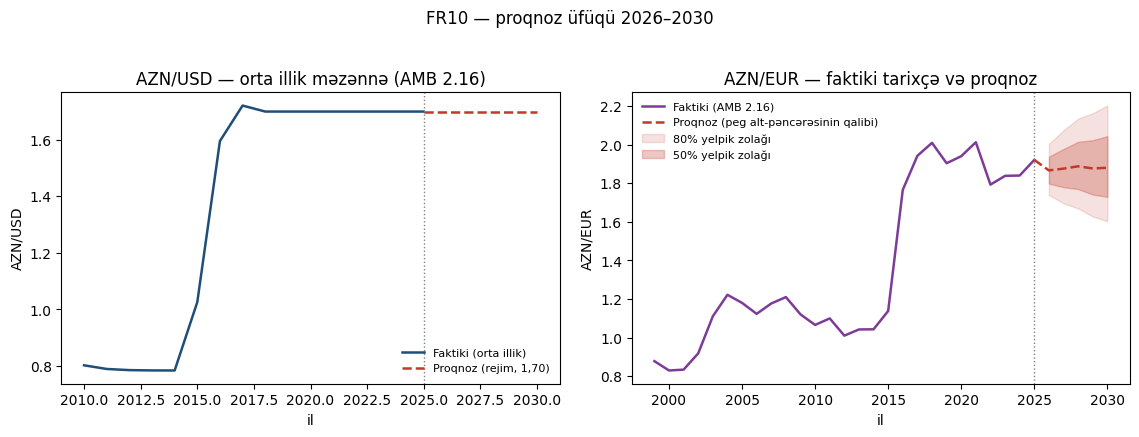

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax = axes[0]
ax.plot(fx_usd_avg.loc[2010:].index, fx_usd_avg.loc[2010:].values, "-", color="#1f4e79",
        lw=1.8, label="Faktiki (orta illik)")
ax.plot([LA] + FY, [fx_usd_avg.loc[LA]] + list(usd_azn_path.values), "--", color="#c0392b",
        lw=1.8, label="Proqnoz (rejim, 1,70)")
ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("AZN/USD — orta illik məzənnə (AMB 2.16)")
ax.set_ylabel("AZN/USD"); ax.set_xlabel("il")
ax.legend(loc="lower right", frameon=False, fontsize=8)

ax = axes[1]
ax.plot(fx_eur.index, fx_eur.values, "-", color="#7d3c98", lw=1.8, label="Faktiki (AMB 2.16)")
ax.plot([LA] + FY, [fx_eur.loc[LA]] + list(eur_azn_path.values), "--", color="#c0392b",
        lw=1.8, label="Proqnoz (peg alt-pəncərəsinin qalibi)")
ax.fill_between(FY, eur_azn_bands["lo80"], eur_azn_bands["hi80"], color="#c0392b", alpha=0.15,
                label="80% yelpik zolağı")
ax.fill_between(FY, eur_azn_bands["lo50"], eur_azn_bands["hi50"], color="#c0392b", alpha=0.28,
                label="50% yelpik zolağı")
ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("AZN/EUR — faktiki tarixçə və proqnoz")
ax.set_ylabel("AZN/EUR"); ax.set_xlabel("il")
ax.legend(loc="upper left", frameon=False, fontsize=8)

fig.suptitle("FR10 — proqnoz üfüqü 2026–2030", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR10_fx_forecast.png"), dpi=140, bbox_inches="tight")
plt.show()

## 8. Nəticələrin ixracı

In [17]:
assumptions_rows = pd.DataFrame([
    {"assumption_key": "usd_azn", "year": y, "value": config.USD_AZN_PEG, "unit": "AZN/USD",
     "note": "rejim fərziyyəsi (sabit valyuta bağlılığı, 2017-ci ildən dəyişməz); baza sırası "
             "AMB cədvəl 2.16-nın RƏSMİ ORTA İLLİK məzənnəsidir (dövrün sonuna deyil) — FR10"}
    for y in FY
] + [
    # DÜZƏLİŞ: burada əvvəllər HƏR il üçün `EUR_CENTRAL` (yəni yolun yalnız 2026 dəyəri)
    # yazılırdı, ona görə fərziyyə faylındakı yol DÜZ xətt çıxırdı, `forecast_long.csv`-dəki
    # nəşr olunan yol isə dəyişirdi — bir kəmiyyət üçün iki fərqli yol. İndi hər il öz dəyərini
    # alır və bu, Bölmə 8.1-də fayldan geri oxunub tutuşdurulur.
    {"assumption_key": "eur_azn", "year": y, "value": float(eur_azn_path.loc[y]), "unit": "AZN/EUR",
     "note": f"AMB cədvəl 2.16 faktiki sırası (1999-{LA}) üzərində iki pəncərəli model yarışı; "
             f"mərkəzi yol peg alt-pəncərəsinin çəkilərindən qurulub ({', '.join(bt_eur_peg.weights)}); "
             f"illik sigma={SIGMA_LOG:.4f} (peg dövründən ÖLÇÜLMÜŞ, ədəbiyyat kalibrləməsi deyil) — FR10"}
    for y in FY
] + [
    # Zolaq da fərziyyə faylına yazılır — FR05-in `brent_usd_lo80/hi80` konvensiyası ilə eyni,
    # ki, aşağı axın mərkəzi yolu qeyri-müəyyənliyindən ayrı götürməsin.
    {"assumption_key": f"eur_azn_{_b}", "year": y, "value": float(eur_azn_bands.loc[y, _b]),
     "unit": "AZN/EUR",
     "note": f"80% yelpik zolağının {'aşağı' if _b == 'lo80' else 'yuxarı'} hüdudu "
             f"(loq səviyyədə σ={SIGMA_LOG:.4f}, √h qaydası ilə genişlənən) — FR10"}
    for _b in ("lo80", "hi80") for y in FY
])
outputs.write_assumptions(assumptions_rows)
assumptions_rows

,assumption_key,year,value,unit,note
0,usd_azn,2026,1.700000,AZN/USD,"rejim fərziyyəsi (sabit valyuta bağlılığı, 201..."
1,usd_azn,2027,1.700000,AZN/USD,"rejim fərziyyəsi (sabit valyuta bağlılığı, 201..."
2,usd_azn,2028,1.700000,AZN/USD,"rejim fərziyyəsi (sabit valyuta bağlılığı, 201..."
3,usd_azn,2029,1.700000,AZN/USD,"rejim fərziyyəsi (sabit valyuta bağlılığı, 201..."
4,usd_azn,2030,1.700000,AZN/USD,"rejim fərziyyəsi (sabit valyuta bağlılığı, 201..."
5,eur_azn,2026,1.866450,AZN/EUR,AMB cədvəl 2.16 faktiki sırası (1999-2025) üzə...
6,eur_azn,2027,1.875817,AZN/EUR,AMB cədvəl 2.16 faktiki sırası (1999-2025) üzə...
7,eur_azn,2028,1.887757,AZN/EUR,AMB cədvəl 2.16 faktiki sırası (1999-2025) üzə...
8,eur_azn,2029,1.876674,AZN/EUR,AMB cədvəl 2.16 faktiki sırası (1999-2025) üzə...
9,eur_azn,2030,1.880083,AZN/EUR,AMB cədvəl 2.16 faktiki sırası (1999-2025) üzə...


In [18]:
def _rows_for(series_code, name_az, unit, actual_s=None, fc_path=None, fc_bands=None):
    rows = []
    if actual_s is not None:
        for y, v in actual_s.items():
            rows.append({"fr": "FR10", "series_code": series_code, "series_name_az": name_az,
                         "unit": unit, "year": int(y), "kind": "actual", "source": "ours",
                         "value": float(v), "lo80": None, "hi80": None, "lo50": None, "hi50": None})
    if fc_path is not None:
        for y in fc_path.index:
            b = fc_bands.loc[y] if fc_bands is not None else None
            rows.append({"fr": "FR10", "series_code": series_code, "series_name_az": name_az,
                         "unit": unit, "year": int(y), "kind": "forecast", "source": "ours",
                         "value": float(fc_path.loc[y]),
                         "lo80": (float(b["lo80"]) if b is not None else None),
                         "hi80": (float(b["hi80"]) if b is not None else None),
                         "lo50": (float(b["lo50"]) if b is not None else None),
                         "hi50": (float(b["hi50"]) if b is not None else None)})
    return rows


fl_rows = []
fl_rows += _rows_for("fx_usd_azn_avg", "ABŞ dollarının rəsmi orta illik məzənnəsi (AMB 2.16)",
                     "AZN/USD", actual_s=fx_usd_avg, fc_path=usd_azn_path)
fl_rows += _rows_for("fx_usd_azn", "ABŞ dollarının orta illik məzənnəsi (iş kitabı)", "AZN/USD",
                     actual_s=fx_usd_wb, fc_path=usd_azn_path)
fl_rows += _rows_for("fx_usd_azn_eop", "ABŞ dollarının məzənnəsi (dövrün sonuna)", "AZN/USD",
                     actual_s=fx_usd_eop, fc_path=usd_azn_path)
fl_rows += _rows_for("fx_eur_azn", "Avronun rəsmi orta illik məzənnəsi (AMB 2.16)", "AZN/EUR",
                     actual_s=fx_eur, fc_path=eur_azn_path, fc_bands=eur_azn_bands)

forecast_long_df = pd.DataFrame(fl_rows)
outputs.write_forecast_long(forecast_long_df)
print(f"forecast_long.csv-ə {len(forecast_long_df)} sətir yazıldı (fr=FR10 əhatəsi yerinə-yazıldı); "
      f"bunlardan {int((forecast_long_df['kind'] == 'actual').sum())} faktiki sətirdir — "
      "əvvəlki buraxılışda AZN/EUR üçün heç bir faktiki sətir yox idi.")
forecast_long_df.head(12)

forecast_long.csv-ə 114 sətir yazıldı (fr=FR10 əhatəsi yerinə-yazıldı); bunlardan 94 faktiki sətirdir — əvvəlki buraxılışda AZN/EUR üçün heç bir faktiki sətir yox idi.


,fr,series_code,series_name_az,unit,year,kind,source,value,lo80,hi80,lo50,hi50
0,FR10,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,AZN/USD,1995,actual,ours,0.882816,NaN,NaN,NaN,NaN
1,FR10,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,AZN/USD,1996,actual,ours,0.860515,NaN,NaN,NaN,NaN
2,FR10,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,AZN/USD,1997,actual,ours,0.797331,NaN,NaN,NaN,NaN
3,FR10,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,AZN/USD,1998,actual,ours,0.773758,NaN,NaN,NaN,NaN
4,FR10,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,AZN/USD,1999,actual,ours,0.823636,NaN,NaN,NaN,NaN
5,FR10,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,AZN/USD,2000,actual,ours,0.894846,NaN,NaN,NaN,NaN
6,FR10,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,AZN/USD,2001,actual,ours,0.931291,NaN,NaN,NaN,NaN
7,FR10,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,AZN/USD,2002,actual,ours,0.972153,NaN,NaN,NaN,NaN
8,FR10,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,AZN/USD,2003,actual,ours,0.982148,NaN,NaN,NaN,NaN
9,FR10,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,AZN/USD,2004,actual,ours,0.982686,NaN,NaN,NaN,NaN


In [19]:
dict_rows = pd.DataFrame([
    {"series_code": "fx_usd_azn_avg",
     "name_az": "ABŞ dollarının rəsmi orta illik məzənnəsi (AMB 2.16)",
     "name_en": "US dollar official average annual exchange rate (CBAR 2.16)",
     "unit": "AZN/USD", "fr": "FR10", "price_basis": "indeks",
     "statutory_sheet_ref": "8 vərəq, 2.4.1.5.-7., sətir 30 (#REF!) — sıra AMB cədvəl 2.16-dan"},
    {"series_code": "fx_eur_azn",
     "name_az": "Avronun rəsmi orta illik məzənnəsi (AMB 2.16)",
     "name_en": "Euro official average annual exchange rate (CBAR 2.16)",
     "unit": "AZN/EUR", "fr": "FR10", "price_basis": "indeks",
     "statutory_sheet_ref": "8 vərəq, 2.4.1.5.-7., sətir 31 (#REF!) — sıra AMB cədvəl 2.16-dan, "
                            "1999–2025; DSK 010en ilə müstəqil tutuşdurulub"},
])
outputs.write_series_dictionary(dict_rows)
dict_rows

,series_code,name_az,name_en,unit,fr,price_basis,statutory_sheet_ref
0,fx_usd_azn_avg,ABŞ dollarının rəsmi orta illik məzənnəsi (AMB...,US dollar official average annual exchange rat...,AZN/USD,FR10,indeks,"8 vərəq, 2.4.1.5.-7., sətir 30 (#REF!) — sıra ..."
1,fx_eur_azn,Avronun rəsmi orta illik məzənnəsi (AMB 2.16),Euro official average annual exchange rate (CB...,AZN/EUR,FR10,indeks,"8 vərəq, 2.4.1.5.-7., sətir 31 (#REF!) — sıra ..."


**Eynilik və müstəqil yoxlama.** Yoxlanan altı qrup:

(i) **nəşr olunan fayllar geri oxunur** — `assumptions.csv`-dəki `usd_azn`, `eur_azn` və zolaq açarları hesablanmış yollarla, `forecast_long.csv`-dəki proqnoz sətirləri isə fərziyyə faylı ilə hər il üzrə tutuşdurulur (əvvəlki buraxılışda bu yoxlama yox idi və `eur_azn` səhvən düz xətt kimi yazılmışdı);
(ii) AZN/EUR mərkəzi yolu alt-pəncərə sınağının çəkilərindən **mexaniki** çıxır — əl seçimi yoxdur. Diqqət: yol təsadüfi gəzişmə DEYİL, ona görə 2025-ci ilin faktiki dəyərinə (1,92100) bərabər olmalı da deyil — 2026 üçün 1,86645, yəni −2,84 %;
(iii) yelpik zolağı düzgün sıralanır, üfüq boyu genişlənir və simulyasiya nəticəsi analitik loq-normal kvantillərlə üst-üstə düşür;
(iv) implisit EUR/USD çarpazı eyniliyi hər faktiki ildə bağlanır;
(v) AMB və DSK mənbələri dərc dəqiqliyi daxilində üst-üstə düşür, 2025-də isə dəqiq eynidir;
(vi) **sınaq pəncərələri** (girişin indeksi deyil) 2025-dən sonrakı ili görmür.

Sonda seçimin dayağı ayrıca qeyd olunur: yuvalanmış pəncərə nəticəsi təsdiqlənir, il-bə-il üstünlüyün isə statistik dayağının zəif olduğu **uğursuzluq kimi deyil, qeyd kimi** yazılır.


In [20]:
v = validate.Verifier("FR10 — Valyuta məzənnəsi")

# --- 1. yolun mexaniki qurulması -------------------------------------------------------------
v.identity("AZN/EUR proqnoz yolu = seçilmiş ansamblın çəkili yolu (mexaniki qurulma), 2026-2030",
           lhs=eur_azn_path,
           rhs=pd.Series({y: sum(bt_eur_peg.weights[m] * _eur_paths[m][y]
                                 for m in bt_eur_peg.weights) for y in FY}), tol=1e-12)

# --- 2. NƏŞR OLUNAN FAYLLARIN GERİ OXUNMASI --------------------------------------------------
# Əvvəlki buraxılışda bu yoxlama YOX idi və məhz buna görə fərziyyə faylındakı `eur_azn`
# düz xətt olduğu halda `forecast_long.csv`-dəki yol dəyişirdi. İndi hər iki fayl geri oxunur.
_asm = outputs.read_assumptions()
v.ok("assumptions.csv-də usd_azn və eur_azn açarları var",
     all(k in _asm for k in ("usd_azn", "eur_azn", "eur_azn_lo80", "eur_azn_hi80")),
     f"mövcud fx açarları: {sorted(k for k in _asm if k.endswith('_azn') or k.startswith('eur_azn'))}")
v.identity("fərziyyə: usd_azn = rejim yolu (hər il)",
           _asm["usd_azn"].reindex(FY), usd_azn_path, tol=1e-12)
v.identity("fərziyyə: eur_azn = mərkəzi yol (hər il, DÜZ xətt DEYİL)",
           _asm["eur_azn"].reindex(FY), eur_azn_path, tol=1e-12)
v.identity("fərziyyə: eur_azn_lo80 (hər il)",
           _asm["eur_azn_lo80"].reindex(FY), eur_azn_bands["lo80"], tol=1e-12)
v.identity("fərziyyə: eur_azn_hi80 (hər il)",
           _asm["eur_azn_hi80"].reindex(FY), eur_azn_bands["hi80"], tol=1e-12)

_fl = pd.read_csv(outputs.FORECAST_LONG_PATH)
_fl_eur = _fl[(_fl["series_code"] == "fx_eur_azn") & (_fl["kind"] == "forecast")].set_index("year")
v.identity("forecast_long AZN/EUR proqnozu = fərziyyə yolu (hər il)",
           _fl_eur["value"], _asm["eur_azn"].reindex(FY), tol=1e-12)
_fl_usd = _fl[(_fl["series_code"] == "fx_usd_azn_avg") & (_fl["kind"] == "forecast")].set_index("year")
v.identity("forecast_long AZN/USD proqnozu = fərziyyə yolu (hər il)",
           _fl_usd["value"], _asm["usd_azn"].reindex(FY), tol=1e-12)

# D1 — hər açarın hər ili üçün yalnız bir sətir
_raw = pd.read_csv(config.ASSUMPTIONS)
_dup = _raw.duplicated(["assumption_key", "year"])
v.ok("assumptions.csv-də təkrarlanan (açar, il) sətri yoxdur (D1)",
     bool(_dup.sum() == 0), f"təkrar sətir sayı: {int(_dup.sum())}")

# --- 3. yelpik zolağı ------------------------------------------------------------------------
v.ok("yelpik zolağı düzgün sıralanıb (lo80 ≤ lo50 ≤ mərkəz ≤ hi50 ≤ hi80)",
     bool((eur_azn_bands["lo80"] <= eur_azn_bands["lo50"]).all()
          and (eur_azn_bands["lo50"] <= eur_azn_path).all()
          and (eur_azn_path <= eur_azn_bands["hi50"]).all()
          and (eur_azn_bands["hi50"] <= eur_azn_bands["hi80"]).all()))
v.ok("zolaq üfüq boyu genişlənir",
     bool(((eur_azn_bands["hi80"] - eur_azn_bands["lo80"]).diff().dropna() > 0).all()),
     f"eni: {(eur_azn_bands['hi80'] - eur_azn_bands['lo80']).round(4).tolist()}")

# Burada parametr qeyri-müəyyənliyi yoxdur, ona görə zolaq TAM loq-normaldır və analitik
# kvantilləri məlumdur; simulyasiyanın qalıq xətası ölçülüb hədd altında saxlanılır.
_h = np.arange(1, len(FY) + 1)
_lp = np.log(eur_azn_path.values)
_an = {"lo80": np.exp(_lp - 1.2816 * SIGMA_LOG * np.sqrt(_h)),
       "hi80": np.exp(_lp + 1.2816 * SIGMA_LOG * np.sqrt(_h)),
       "lo50": np.exp(_lp - 0.6745 * SIGMA_LOG * np.sqrt(_h)),
       "hi50": np.exp(_lp + 0.6745 * SIGMA_LOG * np.sqrt(_h))}
_mc_err = max(float(np.abs(eur_azn_bands[k].values - _an[k]).max()) for k in _an)
v.ok("simulyasiya zolağı analitik loq-normal kvantillərlə uzlaşır (≤ 0,005 AZN)",
     bool(_mc_err <= 5e-3), f"maksimal fərq {_mc_err:.5f} AZN (ndraw = 200 000)")

# --- 4. mənbələr və eyniliklər ---------------------------------------------------------------
v.identity("implisit çarpaz eyniliyi: AZN/EUR = AZN/USD × (EUR/USD), 1999-2025",
           lhs=fx_eur, rhs=fx_usd_avg.reindex(fx_eur.index) * cross, tol=1e-12)
v.ok("AMB 2.16 və DSK 010en yuvarlaqlaşdırma həddi daxilində eynidir",
     bool((data_layer.fx_cross_check()["max_abs_diff"] <= FX_XCHECK_TOL).all()))
v.close("AMB 2.16 və DSK 010en 2025-ci ildə DƏQİQ eynidir",
        float(data_layer.public_series("fx_eur_azn").loc[LA]),
        float(data_layer.public_series("fx_eur_azn_ssc").loc[LA]), tol=5e-5)
v.recompute("yelpik sigması faktiki sıradan müstəqil yenidən hesablanır",
            shipped=SIGMA_LOG,
            fn=lambda: float(np.log(data_layer.public_series("fx_eur_azn")).diff()
                             .dropna().loc[2018:].std()), tol=1e-12)

# --- 5. gələcəyə baxış — SINAQ PƏNCƏRƏLƏRİ üzərində ------------------------------------------
# Əvvəllər burada girişin öz indeksi yoxlanılırdı; o, tərifinə görə ≤ LAST_ACTUAL olduğu üçün
# sınaq haqqında heç nə demirdi. İndi sınaqların FAKTİKİ pəncərələri yoxlanılır.
for _ad, _b in (("AZN/USD, tam", bt_usd), ("AZN/USD, peg", bt_usd_peg),
                ("AZN/USD eop, tam", bt_usd_eop), ("AZN/EUR, tam", bt_eur),
                ("AZN/EUR, peg", bt_eur_peg)):
    v.no_lookahead(f"geriyə doğru sınaq pəncərəsi ({_ad})", pd.Index(_b.common_years))

# --- 6. seçimin dayağı: nə təsdiqlənir, nə təsdiqlənmir --------------------------------------
v.ok("peg alt-pəncərəsinin qalibi YUVALANMIŞ dörd pəncərənin hamısında RW-ni üstələyir "
     "(müstəqil sınaq DEYİL — bax Bölmə 6)", EUR_PEG_ROBUST)
# Aşağıdakı sətir QEYDDİR, yoxlama deyil: `v.ok(..., True)` şəklində yazılsaydı, heç vaxt
# uğursuz ola bilməyən bir «yoxlama» sayğacı şişirdərdi. Ona görə sadəcə çap olunur.
v.assert_all()
print(f"\nQEYD (yoxlama deyil): mərkəzi yolun seçimi kiçik nümunəyə söykənir — "
      f"model {int((_yoy['qalib'] == 'model').sum())}/{len(_yoy)} ildə RW-dən dəqiqdir, "
      f"işarə sınağı p = {EUR_SIGN_P:.3f} (təsadüfdən fərqlənmir). Bax Bölmə 9.")


  YOXLAMA: FR10 — Valyuta məzənnəsi
  [PASS] eynilik: AZN/EUR proqnoz yolu = seçilmiş ansamblın çəkili yolu (mexaniki qurulma), 2026-2030
         5 il, maksimal fərq 0.000e+00
  [PASS] assumptions.csv-də usd_azn və eur_azn açarları var
         mövcud fx açarları: ['eur_azn', 'eur_azn_hi80', 'eur_azn_lo80', 'usd_azn']
  [PASS] eynilik: fərziyyə: usd_azn = rejim yolu (hər il)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: fərziyyə: eur_azn = mərkəzi yol (hər il, DÜZ xətt DEYİL)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: fərziyyə: eur_azn_lo80 (hər il)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: fərziyyə: eur_azn_hi80 (hər il)
         5 il, maksimal fərq 0.000e+00
  [PASS] eynilik: forecast_long AZN/EUR proqnozu = fərziyyə yolu (hər il)
         5 il, maksimal fərq 2.220e-16
  [PASS] eynilik: forecast_long AZN/USD proqnozu = fərziyyə yolu (hər il)
         5 il, maksimal fərq 0.000e+00
  [PASS] assumptions.csv-də təkrarlanan (açar, il) sətri yoxdur 

## 9. Məhdudiyyətlər

**Rejim riski.** 2026–2030 proqnozunun mərkəzi fərziyyəsi — manatın dollara bağlılığının davam etməsi — 2015–2016 presedentinin göstərdiyi kimi siyasət qərarı ilə dəyişə bilər. Bu, ekonometrik modelin deyil, siyasət davamlılığının fərziyyəsidir; hər hansı rəsmi devalvasiya elanı onu etibarsızlaşdırar. AZN/EUR yolu bu fərziyyəyə **iki dəfə** həssasdır: həm manat–dollar bağlılığı, həm də EUR/USD çarpazının öz hərəkəti vasitəsilə.

**Yelpik zolağının pəncərə seçimi.** Sigma peg dövründən (2018–2025, n = 8) qiymətləndirilib və bu, üç namizədin **ən kiçiyidir** (5,55 % ↔ 7,56 % ↔ 10,76 %), yəni zolaq üç variantın ən darıdır. Tam nümunə sigması təxminən iki dəfə böyükdür, çünki 2015–2016 devalvasiyasını əhatə edir; həmin epizod manatın dollara bağlılığının qırılması hadisəsidir və üfüqün rejim fərziyyəsi altında təkrarlanması nəzərdə tutulmur. Seçim Bölmə 5-də hər üç pəncərə və **kalibrləmə cədvəli** ilə birlikdə açıq göstərilir: seçilən sigma tam nümunə üzərində nominal 80 %-in altında əhatə verir (59–75 %), peg dövrü üzərində isə üstündə (87,5–100 %) — lakin sonuncu cəmi 4–8 üst-üstə düşən müşahidəyə əsaslanır. Yəni seçim statistik deyil, **rejim fərziyyəsinə** söykənir.

**Zolağın ikinci riski — rejim qırılmadan da.** Yuxarıdakı qeyd yalnız peg-in qırılması halına aiddir, lakin dar zolağın ikinci, ondan asılı olmayan səbəbi var: manat dollara bağlı qaldıqda belə AZN/EUR-un bütün hərəkəti EUR/USD çarpazından gəlir, çarpazın illik volatilliyi isə peg dövründən **uzun** hər pəncərədə 7,5–8,0 % civarındadır (1999–2025: 7,70 %; 2000–2014: 7,99 %; 2003–2025: 7,49 %) — 2018–2025-in 5,68 %-i müqabilində. Çarpaz öz uzunmüddətli volatilliyinə qayıtsa, zolaq təxminən üçdə bir genişlənməli olardı; bu ehtimal mərkəzi ssenaridə nəzərə alınmır.

**Tam pəncərədə yarışın nəticəsi mənfi bacarıqdır və bu, gizlədilmir.** 2008–2025 pəncərəsində beş namizədin heç biri təsadüfi gəzişməni üstələmir (Bölmə 6); təkcə bu pəncərəyə istinad edilsəydi, mərkəzi yolu etalonun özü daşıyardı. Nəşr olunan mərkəzi yol bu pəncərəyə görə DEYİL, peg alt-pəncərəsinin (2018–2025) yarışına görə seçilir. Tam pəncərənin mənfi nəticəsi modelin zəifliyi deyil, valyuta məzənnələrinin qısa üfüqdə proqnozlaşdırıla bilməzliyinin ölçülmüş təsdiqidir — və yalnız faktiki sıra əldə olduğu üçün ölçülə bildi.

**Mərkəzi yolun seçimi kiçik nümunəyə söykənir.** Peg alt-pəncərəsində `PEG_ORTA3_KROS` RW-ni RMSE-də üstələyir, lakin bu üstünlük səkkiz müşahidəyə əsaslanır və illərin çoxluğundan gəlmir: model 8 ildən 4-ündə RW-dən dəqiqdir (işarə sınağı p = 0,637), qazanc isə əsasən 2022 və 2019 illərində toplanır. Pəncərənin başlanğıc ilinə görə aparılan yoxlama isə **yuvalanmış** pəncərələr üzərindədir və müstəqil sübut sayıla bilməz. Seçim paketin D4 qaydasına (etalonu RMSE-də üstələyən model saxlanılır) tam uyğundur, lakin mərkəzi yolun RW-dən −2,84 % aşağı düşməsinin arxasında güclü statistik dayaq YOXDUR. Alternativ oxunuş — 2025-ci ilin faktiki dəyərinin saxlanılması (1,92100) — yelpiyin 50 % zolağının daxilindədir.

**Orta illik ilə dövrün sonuna arasındakı fərq.** İki anlayış peg dövründə praktik olaraq eynidir, 2015–2016-da isə 0,53 AZN-ə qədər fərqlənir. Paketin bütün digər FR-ləri (dollar ifadəsində göstəricilər) bu buraxılışdan etibarən **orta illik** anlayışını istifadə edir; iş kitabının dövrün sonuna sırası `fx_usd_azn_eop` kodu ilə nəşr olunmaqda davam edir ki, iki uçotun fərqi dashboard-da görünə bilsin.

**Nazirlik müqayisəsi yoxdur.** İş kitabında məzənnə üçün ayrıca Proqnoz sütunu tapılmadığından `ministry_baseline(...)` overlay-i bu FR-də göstərilmir (Bölmə 2).